# Atividade — Explorando Árvores de Decisão para Classificação

## Objetivo

Nesta atividade, você irá resolver um problema de **classificação** utilizando Árvores de Decisão e investigar como diferentes escolhas influenciam o modelo.

Você deverá:
- construir árvores de decisão para um conjunto de dados real;
- comparar diferentes critérios de particionamento;
- observar quais atributos são escolhidos pela árvore;
- visualizar os primeiros níveis das árvores;
- investigar o efeito da profundidade sobre o desempenho;
- utilizar um mecanismo de **parada antecipada (pre-pruning)**;
- comparar desempenho e complexidade;
- escolher e justificar um modelo final.

> **Importante:** todas as respostas devem ser preenchidas no próprio notebook, nas células indicadas.

## 1. Conjunto de dados

Será utilizado o conjunto **Bank Marketing**, disponibilizado pelo UCI Machine Learning Repository.

O problema consiste em prever se um cliente irá contratar (`yes`) ou não (`no`) um depósito a prazo após uma campanha de marketing bancário.

O arquivo utilizado é `bank-full.csv`, com separador `;`.

O conjunto possui 45.211 instâncias e atributos numéricos e categóricos.

**Fonte:** UCI Machine Learning Repository — Bank Marketing

O arquivo `bank-full.csv` deve estar na mesma pasta deste notebook.

## 2. Importação das bibliotecas

Execute a célula a seguir. O código inicial já contém as principais bibliotecas necessárias.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay
)

## 3. Carregamento dos dados

Execute o código abaixo e observe as primeiras linhas.

In [2]:
df = pd.read_csv("bank-full.csv", sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### Questão 1 — Conhecendo os dados

Investigue o conjunto utilizando `shape`, `info`, `describe` e outros comandos que considerar adequados.

Responda:
1. Quantas instâncias existem?
2. Quantos atributos existem?
3. Qual é a variável-alvo?
4. Quais atributos são numéricos?
5. Quais atributos são categóricos?

**Resposta:**

In [3]:
# Utilize esta célula para sua investigação.
# Exemplos:
df.shape
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
count,45211.000000,45211,45211,45211,45211,45211.000000,45211,45211,45211,45211.000000,45211,45211.000000,45211.000000,45211.000000,45211.000000,45211,45211
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,blue-collar,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,9732,27214,23202,44396,NaN,25130,37967,29285,NaN,13766,NaN,NaN,NaN,NaN,36959,39922
mean,40.936210,NaN,NaN,NaN,NaN,1362.272058,NaN,NaN,NaN,15.806419,NaN,258.163080,2.763841,40.197828,0.580323,NaN,NaN
std,10.618762,NaN,NaN,NaN,NaN,3044.765829,NaN,NaN,NaN,8.322476,NaN,257.527812,3.098021,100.128746,2.303441,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,-8019.000000,NaN,NaN,NaN,1.000000,NaN,0.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,33.000000,NaN,NaN,NaN,NaN,72.000000,NaN,NaN,NaN,8.000000,NaN,103.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,448.000000,NaN,NaN,NaN,16.000000,NaN,180.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,48.000000,NaN,NaN,NaN,NaN,1428.000000,NaN,NaN,NaN,21.000000,NaN,319.000000,3.000000,-1.000000,0.000000,NaN,NaN


**Escreva sua resposta aqui.**
1. 45211 instâncias.
2. 17 atributos.
3. A coluna y
4. Age, balance, day, duration, campaign, pdays e previous
5. Job, marital, education, default, housing, loan, contact, month, poutcome e y

## 4. Distribuição das classes

Investigue a distribuição da variável-alvo.

In [4]:
df["y"].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [ ]:
df["y"].value_counts(normalize=True)

,proportion
y,
no,0.883015
yes,0.116985


### Questão 2 — Distribuição das classes

1. As classes estão balanceadas?
2. Qual é a classe majoritária?
3. Por que o desbalanceamento deve ser considerado na avaliação de um classificador?

**Resposta:**

**Escreva sua resposta aqui.**
1. Não.
2. A classe "no".
3. Por conta da proporção que será usada nos treinos e nos testes.

## 5. Preparação dos dados

Separe os atributos da variável-alvo. Os atributos categóricos serão transformados em uma representação numérica por One-Hot Encoding.

In [ ]:
X = df.drop("y", axis=1)
y = df["y"].map({"no": 0, "yes": 1})

categorical_features = X.select_dtypes(include=["object"]).columns
numeric_features = X.select_dtypes(exclude=["object"]).columns

print("Categóricos:", list(categorical_features))
print("Numéricos:", list(numeric_features))

Categóricos: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Numéricos: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

X_encoded = preprocessor.fit_transform(X)

print("Dimensão original:", X.shape)
print("Dimensão após codificação:", X_encoded.shape)

Dimensão original: (45211, 16)
Dimensão após codificação: (45211, 51)


### Questão 3 — Explique o código acima faz. Como funciona o OneHotEncoder?
**Resposta:**
O código usa o ColumnTransformer para aplicar transformações nas colunas categóricas. A transformação aplicada é a OneHotEncoder, que divide colunas categóricas em binárias, onde o 1 e o 0 indicam a presença e a ausência da característica anteriormente categórica. O fit_transform gera os dados transformados.

## 6. Separação entre treinamento e teste

Utilize 70% dos dados para treinamento e 30% para teste.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Treinamento:", X_train.shape)
print("Teste:", X_test.shape)

Treinamento: (31647, 51)
Teste: (13564, 51)


### Questão 4 — Treinamento e teste

Explique por que o conjunto de teste não deve ser utilizado para ajustar o modelo.

Em sua resposta, explique a relação entre treinamento, teste, generalização e overfitting.

**Resposta:**

**Escreva sua resposta aqui.**
Caso o conjunto de teste seja utilizado para ajustar o modelo, quando o modelo for testá-lo, já conhecerá todos aqueles testes, o que gerará um resultado enviesado.

O treinamento serve para conhecer os dados a serem utilizados e aprender seus padrões, já o teste serve para testar os resultados do treinamento em um conjunto novo de dados que não eram conhecidos previamentes. A generalização define a capacidade de um modelo de prever um teste com sucesso, que pode ser atrapalhada com overfitting, fenômeno descrito pelo treino de um conjunto complexo usando dados insuficientes.

# Parte I — Critérios de particionamento

## 7. Árvore de Decisão com Gini

Construa uma árvore utilizando o critério `gini`.

Inicialmente, **não limite a profundidade**. O objetivo é observar uma árvore que cresça livremente.

In [ ]:
tree_gini = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

tree_gini.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_gini = tree_gini.predict(X_test)

print("Acurácia:", accuracy_score(y_test, y_pred_gini))
print("Precisão:", precision_score(y_test, y_pred_gini))
print("Recall:", recall_score(y_test, y_pred_gini))
print("F1:", f1_score(y_test, y_pred_gini))
print("Profundidade:", tree_gini.get_depth())
print("Número de folhas:", tree_gini.get_n_leaves())

Acurácia: 0.8731200235918608
Precisão: 0.45934466019417475
Recall: 0.47700063011972277
F1: 0.4680061823802164
Profundidade: 36
Número de folhas: 2562


## 8. Visualização da árvore

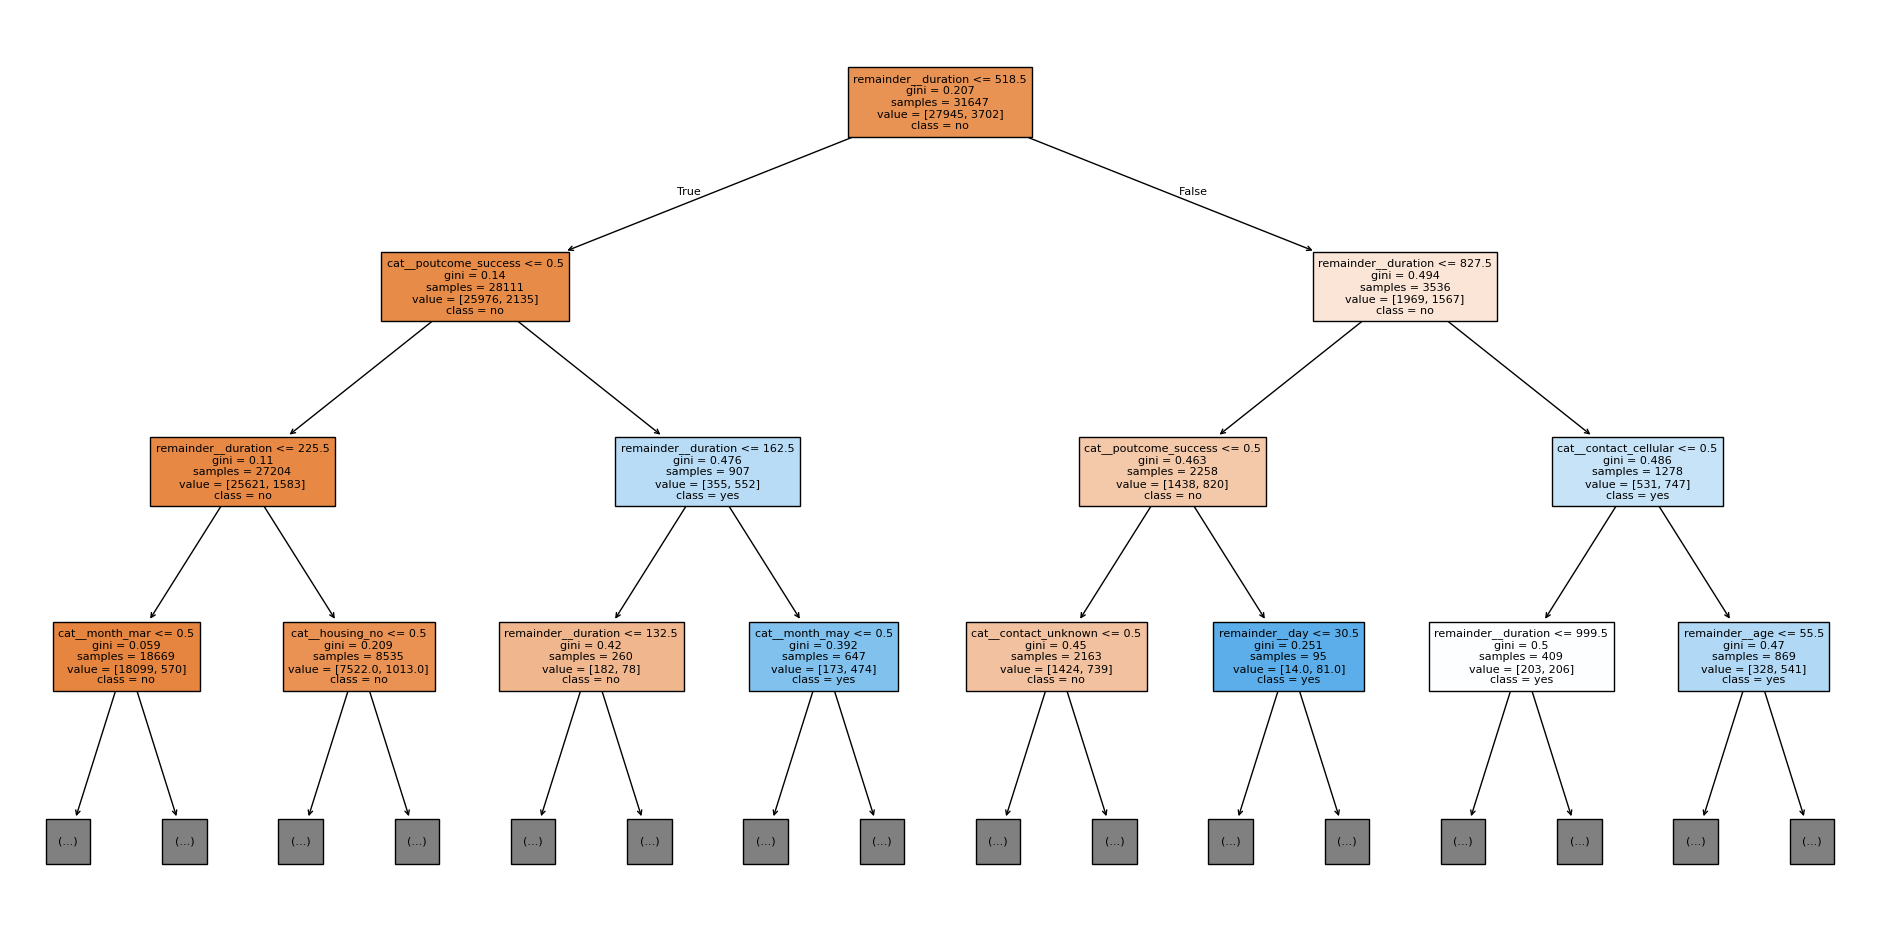

In [ ]:
feature_names = preprocessor.get_feature_names_out()

plt.figure(figsize=(24, 12))
plot_tree(
    tree_gini,
    max_depth=3,
    feature_names=feature_names,
    class_names=["no", "yes"],
    filled=True,
    fontsize=8
)
plt.show()

### Questão 5 — Observando os particionamentos

Observe os primeiros níveis da árvore.

1. Qual atributo foi escolhido na raiz?
2. Qual condição de particionamento foi utilizada?
3. Quais atributos aparecem nos níveis seguintes?
4. O atributo escolhido na raiz é necessariamente o atributo mais importante de todo o modelo? Explique.
5. O que representam `gini`, `samples`, `value` e `class` em um nó?

**Resposta:**

**Escreva sua resposta aqui.**

## 9. Árvore de Decisão com Entropy

Agora construa outra árvore, utilizando `entropy` como critério.

In [ ]:
tree_entropy = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

tree_entropy.fit(X_train, y_train)

y_pred_entropy = tree_entropy.predict(X_test)

print("Acurácia:", accuracy_score(y_test, y_pred_entropy))
print("Precisão:", precision_score(y_test, y_pred_entropy))
print("Recall:", recall_score(y_test, y_pred_entropy))
print("F1:", f1_score(y_test, y_pred_entropy))
print("Profundidade:", tree_entropy.get_depth())
print("Número de folhas:", tree_entropy.get_n_leaves())

Acurácia: 0.8805662046593925
Precisão: 0.4892367906066536
Recall: 0.4725897920604915
F1: 0.4807692307692308
Profundidade: 36
Número de folhas: 2358


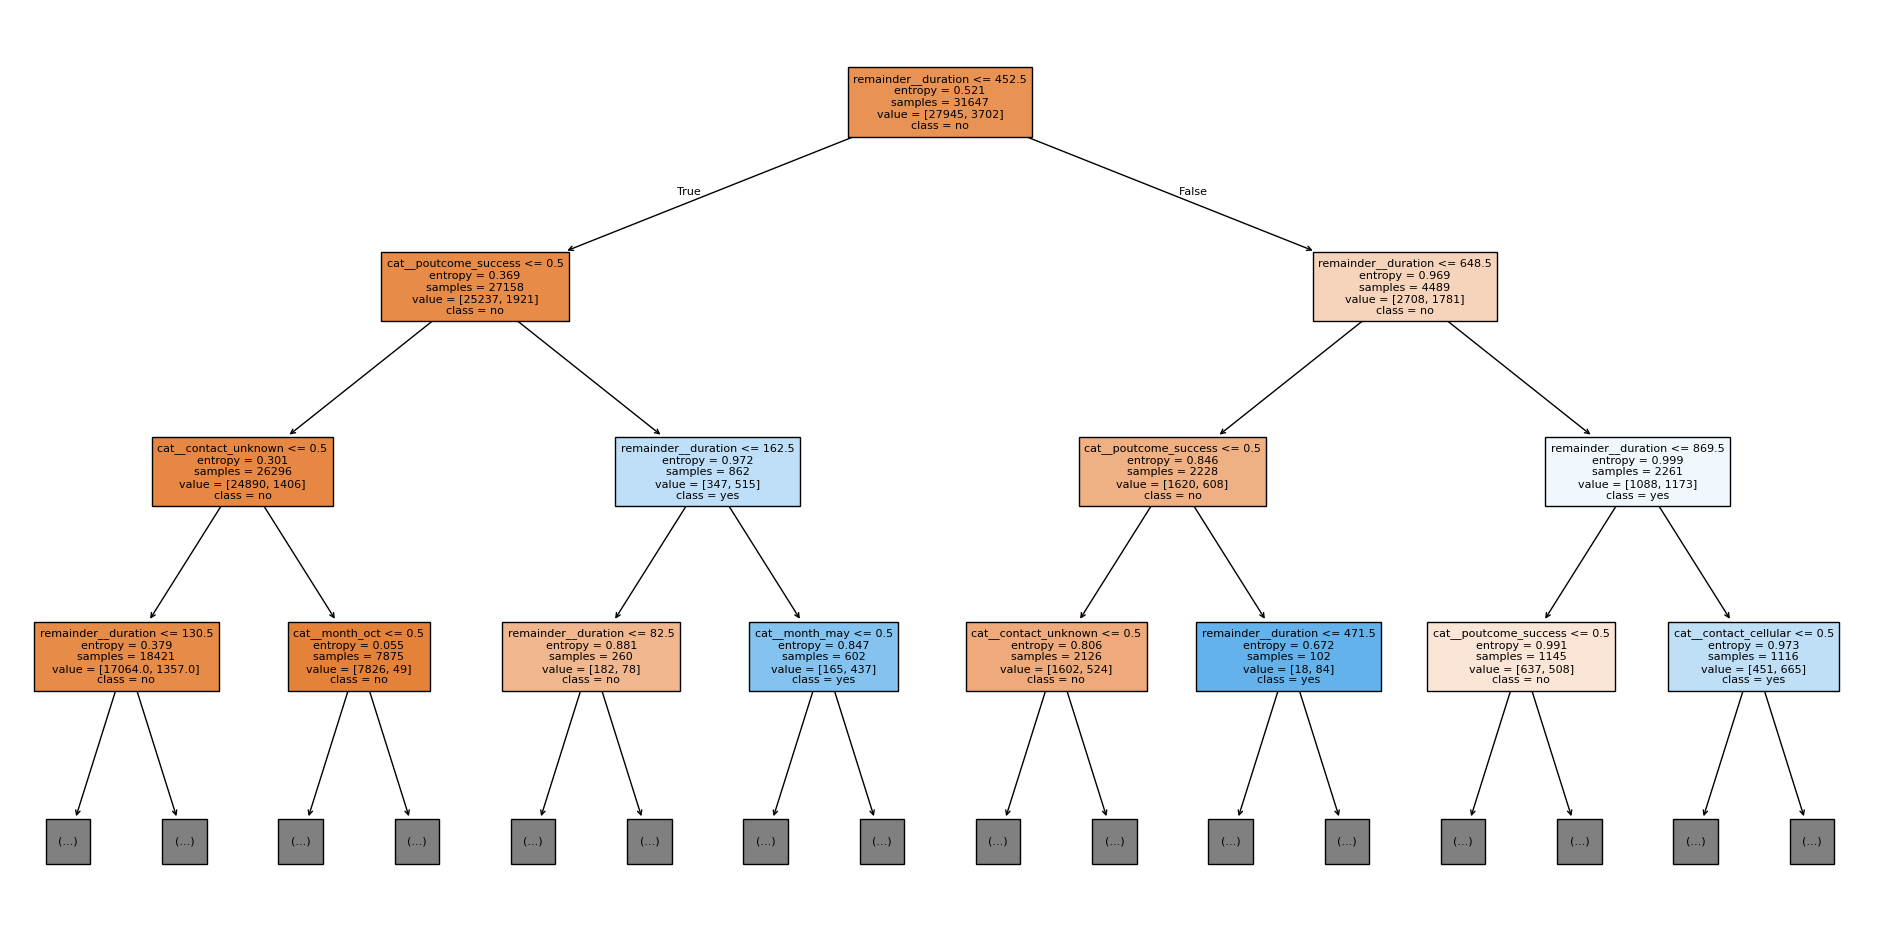

In [ ]:
plt.figure(figsize=(24, 12))
plot_tree(
    tree_entropy,
    max_depth=3,
    feature_names=feature_names,
    class_names=["no", "yes"],
    filled=True,
    fontsize=8
)
plt.show()

### Questão 6 — Gini × Entropy

Preencha a tabela:

| Característica | Gini | Entropy |
|---|---:|---:|
| Acurácia | | |
| Precisão | | |
| Recall | | |
| F1 | | |
| Profundidade | | |
| Número de folhas | | |
| Atributo da raiz | | |

Depois responda:
1. As árvores são iguais?
2. O atributo escolhido na raiz é o mesmo?
3. A ordem dos atributos é a mesma?
4. Qual árvore é mais complexa?
5. Qual apresentou melhor desempenho no teste?
6. Uma diferença pequena de desempenho permite afirmar que um critério é sempre melhor que o outro?

**Resposta:**

**Escreva sua resposta aqui.**

# Parte II — Parada antecipada

## 10. Investigando o crescimento da árvore


Uma das características das Árvores de Decisão é que sua complexidade pode ser controlada por meio do parâmetro `max_depth`.

Até o momento, foram construídos modelos utilizando uma única configuração de profundidade. Agora, você deverá investigar **como o desempenho e a complexidade da árvore variam à medida que sua profundidade máxima aumenta**.

Considere os seguintes valores para `max_depth`:

```python
[2, 3, 4, 5, 6, 8, 10, 15, 20, None]
```

O valor `None` representa uma árvore sem uma restrição explícita de profundidade.

#### Tarefa

Escreva um código que, para **cada valor de `max_depth`**:

1. crie uma nova `DecisionTreeClassifier`, utilizando o critério `gini`;
2. treine o modelo utilizando `X_train` e `y_train`;
3. realize previsões tanto no conjunto de treinamento quanto no conjunto de teste;
4. calcule a **acurácia no treinamento**;
5. calcule a **acurácia no teste**;
6. calcule o **F1-score no teste**;
7. obtenha a profundidade efetivamente alcançada pela árvore;
8. obtenha o número de folhas da árvore;
9. armazene todos esses resultados para posterior comparação.

Ao final, organize os resultados em um `DataFrame` chamado `results_df`.

O `DataFrame` deverá permitir comparar, para cada profundidade, pelo menos as seguintes informações:

| Informação       | Descrição                          |
| ---------------- | ---------------------------------- |
| `max_depth`      | Limite de profundidade utilizado   |
| `train_accuracy` | Acurácia no treinamento            |
| `test_accuracy`  | Acurácia no teste                  |
| `test_f1`        | F1-score no teste                  |
| `tree_depth`     | Profundidade efetivamente atingida |
| `leaves`         | Número de folhas                   |

**Restrição:** não crie manualmente um modelo para cada profundidade. Utilize uma estrutura de repetição para executar o experimento automaticamente.


In [ ]:
##seu código aqui

Usando o dataframe criado, observe o efeito da profundidade sobre o desempenho.

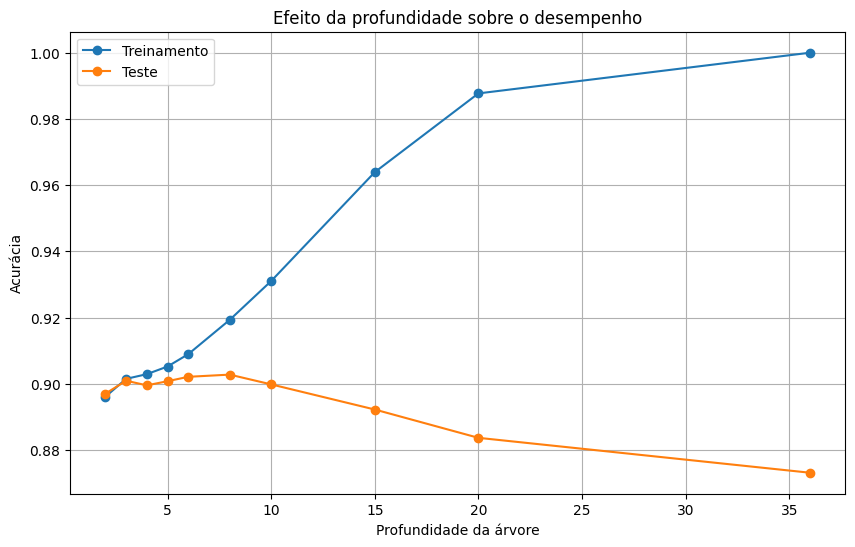

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(results_df["tree_depth"], results_df["train_accuracy"],
         marker="o", label="Treinamento")
plt.plot(results_df["tree_depth"], results_df["test_accuracy"],
         marker="o", label="Teste")
plt.xlabel("Profundidade da árvore")
plt.ylabel("Acurácia")
plt.title("Efeito da profundidade sobre o desempenho")
plt.legend()
plt.grid()
plt.show()

### Questão 7 — Efeito da profundidade

1. O que acontece com a acurácia de treinamento quando a árvore cresce?
2. O comportamento da acurácia de teste é igual?
3. Existe uma profundidade a partir da qual aumentar a complexidade deixa de produzir benefícios claros?
4. Em qual profundidade você escolheria trabalhar?
5. Justifique sua escolha considerando **desempenho e complexidade**.

**Resposta:**

**Escreva sua resposta aqui.**

## 11. Construindo o modelo com parada antecipada

Escolha uma profundidade com base na análise anterior.

> Altere `SUA_PROFUNDIDADE` para o valor escolhido por você.

In [ ]:
SUA_PROFUNDIDADE = 5  # altere após sua análise

tree_pruned = DecisionTreeClassifier(
    criterion="gini",
    max_depth=SUA_PROFUNDIDADE,
    random_state=42
)

tree_pruned.fit(X_train, y_train)
y_pred_pruned = tree_pruned.predict(X_test)

print("Acurácia:", accuracy_score(y_test, y_pred_pruned))
print("Precisão:", precision_score(y_test, y_pred_pruned))
print("Recall:", recall_score(y_test, y_pred_pruned))
print("F1:", f1_score(y_test, y_pred_pruned))
print("Profundidade:", tree_pruned.get_depth())
print("Número de folhas:", tree_pruned.get_n_leaves())

Acurácia: 0.9007667354762607
Precisão: 0.6393063583815028
Recall: 0.3484562066792691
F1: 0.45106035889070145
Profundidade: 5
Número de folhas: 31


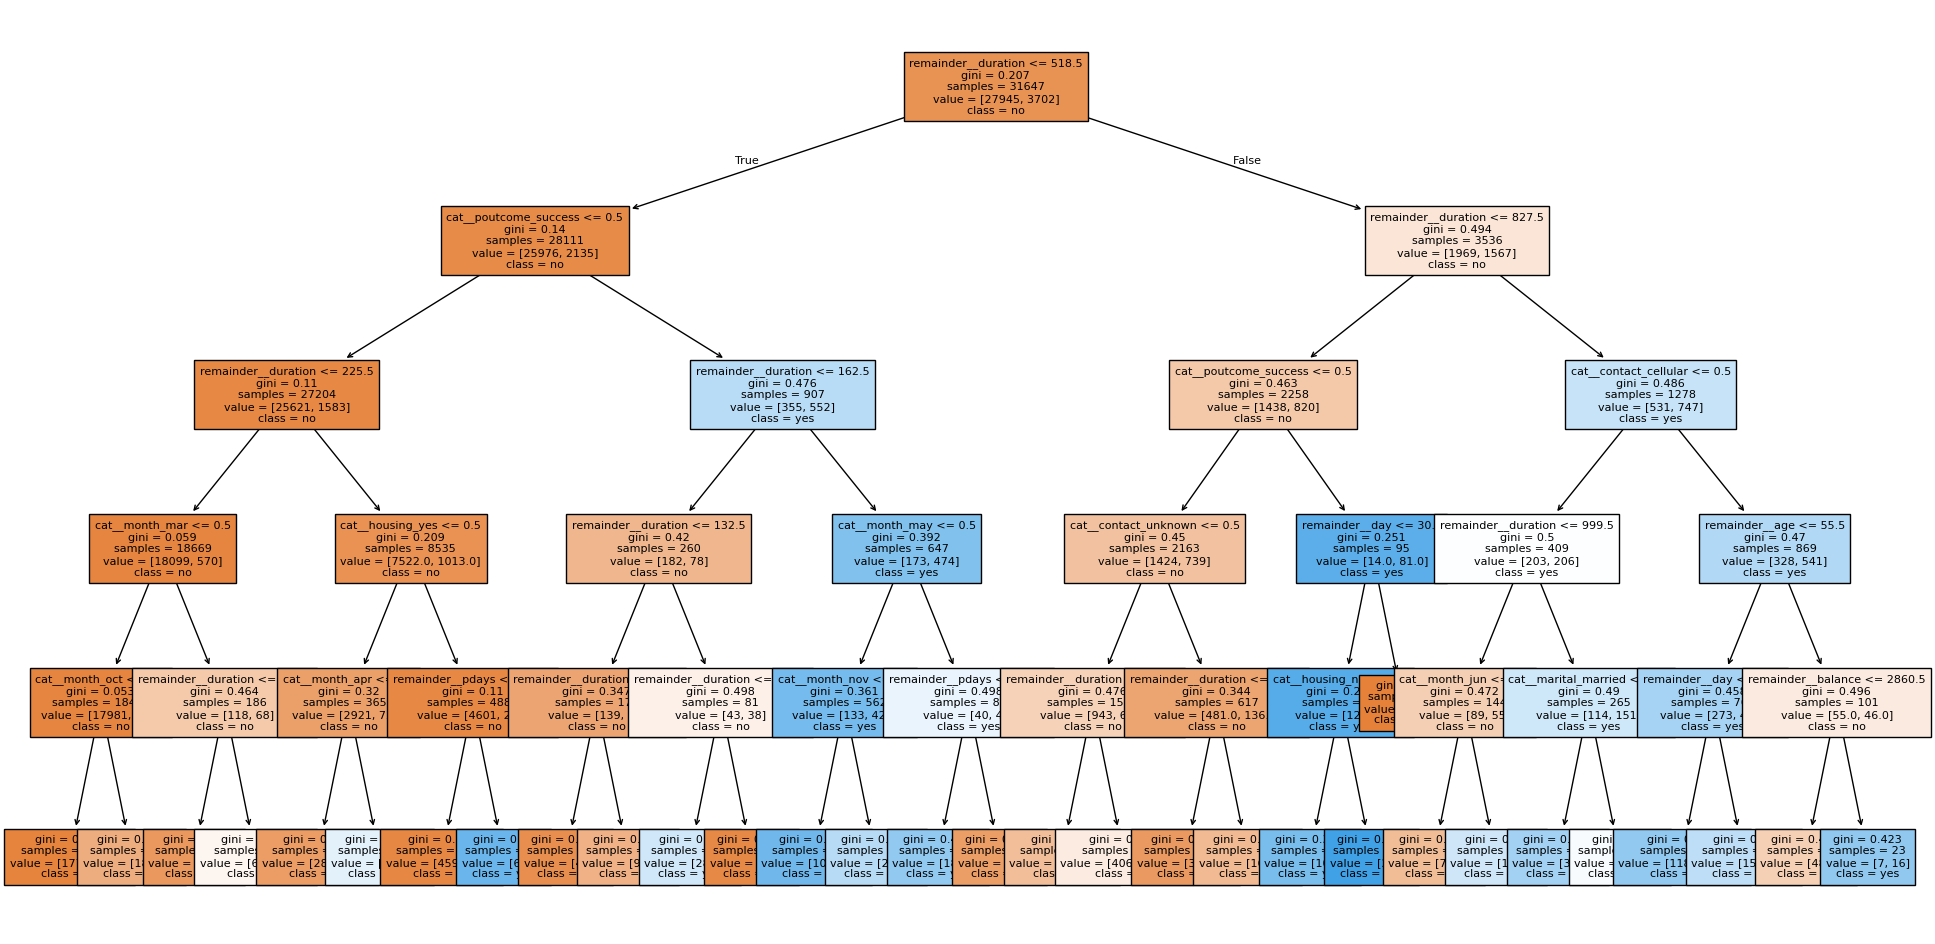

In [ ]:
plt.figure(figsize=(24, 12))
plot_tree(
    tree_pruned,
    feature_names=feature_names,
    class_names=["no", "yes"],
    filled=True,
    fontsize=8
)
plt.show()

# Parte III — Análise dos atributos

## 12. Importância dos atributos

O código a seguir calcula as importâncias dos atributos e as ordena.

In [ ]:
importance = pd.DataFrame({
    "feature": feature_names,
    "importance": tree_gini.feature_importances_
}).sort_values("importance", ascending=False)

importance.head(15)

,feature,importance
47,remainder__duration,0.279931
45,remainder__balance,0.095818
44,remainder__age,0.093600
46,remainder__day,0.089978
42,cat__poutcome_success,0.089024
49,remainder__pdays,0.039845
48,remainder__campaign,0.031905
21,cat__housing_no,0.017494
28,cat__month_apr,0.015839
35,cat__month_mar,0.014490


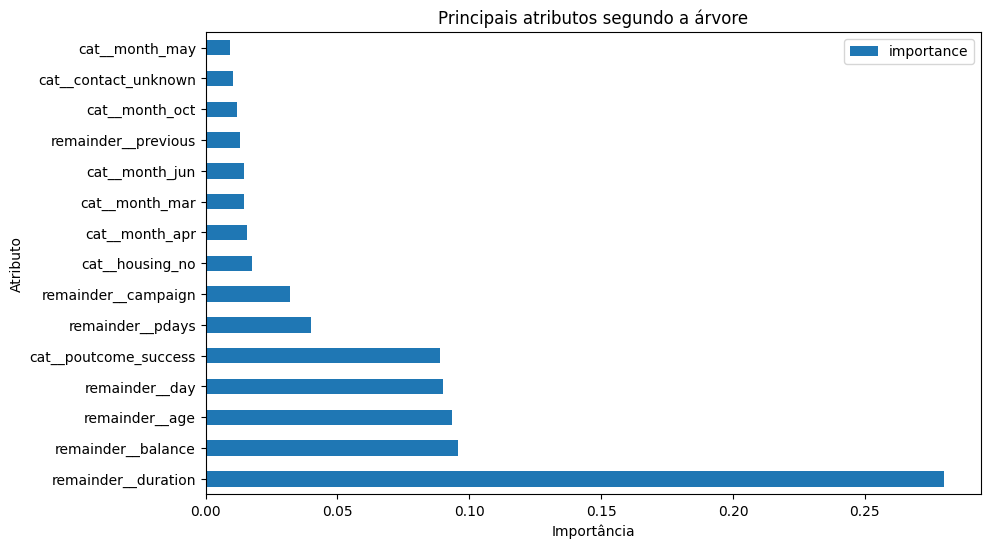

In [ ]:
importance.head(15).plot(
    x="feature",
    y="importance",
    kind="barh",
    figsize=(10, 6)
)
plt.xlabel("Importância")
plt.ylabel("Atributo")
plt.title("Principais atributos segundo a árvore")
plt.show()

### Questão 8 — Atributos escolhidos

1. Quais são os cinco atributos com maior importância?
2. O atributo utilizado na raiz está entre os mais importantes?
3. Um atributo que aparece em um nível profundo da árvore necessariamente é menos importante?
4. Explique a diferença entre:
   - atributo escolhido para o primeiro particionamento;
   - atributo com maior importância no modelo.

**Resposta:**

**Escreva sua resposta aqui.**

# Parte IV — Comparação final

## 13. Comparando os modelos

Compare:
1. Gini sem restrição;
2. Entropy sem restrição;
3. Gini com parada antecipada.

In [ ]:
comparison = pd.DataFrame({
    "Modelo": [
        "Gini - sem restrição",
        "Entropy - sem restrição",
        "Gini - parada antecipada"
    ],
    "Acurácia": [
        accuracy_score(y_test, tree_gini.predict(X_test)),
        accuracy_score(y_test, tree_entropy.predict(X_test)),
        accuracy_score(y_test, tree_pruned.predict(X_test))
    ],
    "Precisão": [
        precision_score(y_test, tree_gini.predict(X_test)),
        precision_score(y_test, tree_entropy.predict(X_test)),
        precision_score(y_test, tree_pruned.predict(X_test))
    ],
    "Recall": [
        recall_score(y_test, tree_gini.predict(X_test)),
        recall_score(y_test, tree_entropy.predict(X_test)),
        recall_score(y_test, tree_pruned.predict(X_test))
    ],
    "F1": [
        f1_score(y_test, tree_gini.predict(X_test)),
        f1_score(y_test, tree_entropy.predict(X_test)),
        f1_score(y_test, tree_pruned.predict(X_test))
    ],
    "Profundidade": [
        tree_gini.get_depth(),
        tree_entropy.get_depth(),
        tree_pruned.get_depth()
    ],
    "Folhas": [
        tree_gini.get_n_leaves(),
        tree_entropy.get_n_leaves(),
        tree_pruned.get_n_leaves()
    ]
})

comparison

,Modelo,Acurácia,Precisão,Recall,F1,Profundidade,Folhas
0,Gini - sem restrição,0.873120,0.459345,0.477001,0.468006,36,2562
1,Entropy - sem restrição,0.880566,0.489237,0.472590,0.480769,36,2358
2,Gini - parada antecipada,0.900767,0.639306,0.348456,0.451060,5,31


### Questão 9 — Escolha do modelo final

Com base nos resultados:

1. Qual modelo apresenta o melhor desempenho?
2. Qual modelo apresenta menor complexidade?
3. Existe um modelo que ofereça um bom compromisso entre desempenho e interpretabilidade?
4. Qual modelo você escolheria para uma aplicação real? Justifique.

**Resposta:**

**Escreva sua resposta aqui.**

# 15. Outro mecanismo de parada

Escolha **um** dos parâmetros abaixo e faça um pequeno experimento:
- `min_samples_split`;
- `min_samples_leaf`;
- `min_impurity_decrease`.

Compare-o com o modelo obtido utilizando `max_depth`.

Responda:
1. Qual parâmetro você escolheu?
2. Qual é seu efeito?
3. Como ele alterou a árvore?
4. Como alterou o desempenho?
5. Qual mecanismo de parada você considera mais adequado para este conjunto de dados?

**Resposta:**

In [ ]:
# Desenvolva aqui o experimento do desafio.